# Import libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
#This function generates a fake regression dataset for practice and testing.
from sklearn.datasets import make_regression

#This function performs cross-validation to evaluate a model.
from sklearn.model_selection import cross_val_score

# generate_fake_regression_dataset

In [40]:
X, y = make_regression(

    n_samples= 100, # 100 rows
    n_features= 1,  # 1 input feature
    noise= 10,
    n_targets=1,
    n_informative=1,
    random_state=13

)
print(X.shape)
print(y.shape)


(100, 1)
(100,)


# scatter_plot

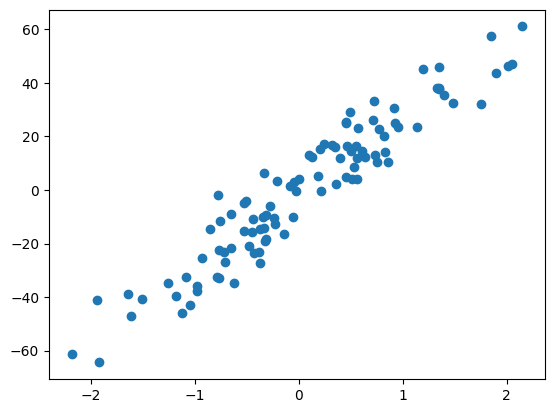

In [41]:
plt.scatter(X,y)

# apply_Regression

In [42]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state= 42
)

In [43]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

# fit_model()

In [44]:
lr.fit(X_train,y_train)
print(f"Coeffecient : {lr.coef_}")
print(f"Intercept : {lr.intercept_}")

Coeffecient : [27.88617433]
Intercept : -1.3565362834620514


> We find the coeffecient and intercept. Now we will set Random coeffeciant and intercept then apply Gradient Descent to see, Does the randome m,b value changed and become the exact m,b value we measured in prevous section



# Gradient_DRegressor

In [48]:
class GDRegressor :

  def __init__(self,learning_rate,epochs) :

    self.m = 100 # Initial guess for slope (m)
    self.b = -60  # Initial guess for intercept (b)
    self.learning_rate = learning_rate # Learning rate controls how big each update step is
    self.epochs = epochs  # Number of times Gradient Descent will run

  def fit(self,X,y):
    for i in range(self.epochs):
      loss_b = -2 * np.sum(y- self.m*X.ravel() - self.b) #X is 2d shape, Ravel make it 1D flatten
      loss_m = -2 * np.sum((y - self.m*X.ravel() - self.b)*X.ravel())

      self.b = self.b - (self.learning_rate * loss_b)
      self.m = self.m -(self.learning_rate * loss_m)

      #Final learned value
      print(self.m , self.b)

  def predict(self,X):
    #use learned m and b to predict
    return self.m *X + self.b
  def get_params(self):
        return self.m, self.b

gd = GDRegressor(0.001,100) #pass the learning_rate and epochs
gd.fit(X,y)
m, b = gd.get_params()



88.0835301055913 -49.07383273169124
78.11733063958334 -40.19369693340169
69.7852288146696 -32.973168352678265
62.82166966491227 -27.09941422202686
57.00374934885524 -22.31906625289887
52.14447260088697 -18.426825968084223
48.08705279085912 -15.256270204690603
44.70009849103518 -12.67242893279743
41.87355267116916 -10.565791282365609
39.51526996767661 -8.847462928561056
37.54813421391478 -7.445252017457852
35.90763287163554 -6.300504235093494
34.539817443729675 -5.3655425284869125
33.39958962698256 -4.601595057058761
32.44926210800582 -3.9771175334983795
31.6573507191894 -3.4664342844263714
30.997561334975714 -3.0486369895207113
30.447940561171478 -2.7066918382685183
29.990164090927646 -2.4267153341631573
29.608940692162903 -2.1973866250077947
29.29151325831769 -2.0094704048503056
29.02724128890683 -1.8554294070664452
28.807251647313223 -1.7291095215820498
28.624146538509127 -1.6254838089855697
28.471759417128048 -1.5404443005662032
28.344951026364186 -1.4706325869898595
28.239439023096

# After applying GD

In [49]:
print("\nAfter Gradient Descent:")
print("Slope (m):", gd.m)
print("Intercept (b):", gd.b)


After Gradient Descent:
Slope (m): 27.71820044499814
Intercept (b): -1.1473725462824265


 > We set m= 100, b= -60 , the we apply gradient descent and the model became give the prevous m,b like exactly the same